# Tunisian ASR — Audio Preprocessing (`02_audio_preprocessing`)

**Scope:** segment extraction, optional gap smoothing, waveform preprocessing,  
quality filtering, Arrow/Parquet storage, and output statistics.

**Inputs:**
- `data/raw/linagora/` — original HuggingFace dataset (audio bytes + segments)
- `data/interim/text_clean/df_train_clean.parquet` + `df_test_clean.parquet`
  — enriched segment DataFrames from Phase 3 (contain `seg_start`/`seg_end`)

**Outputs:**
- `data/interim/02_audio_clean/{train,test}/manifest.parquet` — full metadata per segment
- `data/interim/02_audio_clean/{train,test}/segments.arrow` — preprocessed waveforms (kept only)
- `outputs/figures/audio_*.png` — distribution plots

### Road-map
| § | Section | Key output |
|---|---------|-----------|
| 1 | Environment & config | — |
| 2 | Load data | `df_train`, `df_test`, HF dataset |
| 3 | Gap & silence analysis | plots (reuse from audit) |
| 4 | Optional smoothing | updated `seg_start`/`seg_end` |
| 5 | Preprocessing spot-check | verify transforms on 5 samples |
| 6 | Full extraction loop | Arrow + manifest files |
| 7 | Post-processing statistics | duration/RMS/quality plots |
| 8 | Summary report | — |

## 1 · Environment & Config

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

PROJECT_ROOT = str(Path.cwd().parent)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

from src.utils               import load_config, ensure_dir, print_dict, print_section
from src.data_loader         import load_local_dataset
from src.audit_audio         import (
    segment_gap_stats, visualize_gap_distribution,
    segment_duration_stats, enrich_audio_features,
)
from src.audio_preprocessing import (
    df_gap_stats, plot_gap_distribution, outputs_exist,
    apply_smoothing_to_df, smoothing_summary,
    decode_audio_bytes, slice_segment, full_preprocess,
    compute_segment_quality, passes_quality_gate,
    iter_segments, save_segments_arrow, load_manifest,
    compute_corpus_stats,
)

print("✓ imports OK")

✓ imports OK


In [5]:
# ── Load all configs ─────────────────────────────────────────────────────
paths     = load_config(f"{PROJECT_ROOT}/configs/paths.yaml")
audio_cfg = load_config(f"{PROJECT_ROOT}/configs/audio_config.yaml")

# ── Resolve paths ─────────────────────────────────────────────────────────
DATA_PATH      = f"{PROJECT_ROOT}/{paths['data']['raw']}"
TEXT_CLEAN_DIR = f"{PROJECT_ROOT}/{paths['interim']['text_clean']}"
AUDIO_OUT_DIR  = f"{PROJECT_ROOT}/{paths['interim']['audio_clean']}"
FIGURES_PATH   = f"{PROJECT_ROOT}/{paths['outputs']['figures']}"
REPORTS_PATH   = f"{PROJECT_ROOT}/{paths['outputs']['reports']}"

ensure_dir(AUDIO_OUT_DIR)
ensure_dir(FIGURES_PATH)
ensure_dir(REPORTS_PATH)

# ── Config shortcuts ──────────────────────────────────────────────────────
SMOOTH_CFG  = audio_cfg["smoothing"]
PP_CFG      = audio_cfg["preprocessing"]
GATE_CFG    = audio_cfg["quality_gate"]
STORE_CFG   = audio_cfg["storage"]
DISP_CFG    = audio_cfg["display"]

SMOOTHING_ENABLED = SMOOTH_CFG["enabled"]

print(f"DATA_PATH     : {DATA_PATH}")
print(f"TEXT_CLEAN_DIR: {TEXT_CLEAN_DIR}")
print(f"AUDIO_OUT_DIR : {AUDIO_OUT_DIR}")
print()
print(f"Smoothing enabled : {SMOOTHING_ENABLED}")
print(f"Target SR         : {PP_CFG['target_sr']} Hz")
print(f"Quality gate      : min={GATE_CFG['min_duration_s']}s  max={GATE_CFG['max_duration_s']}s  min_rms={GATE_CFG['min_rms']}")

DATA_PATH     : C:\Users\MSI\Desktop\ASR\asr_tn_pielines/data/raw/linagora
TEXT_CLEAN_DIR: C:\Users\MSI\Desktop\ASR\asr_tn_pielines/data/interim/text_clean
AUDIO_OUT_DIR : C:\Users\MSI\Desktop\ASR\asr_tn_pielines/data/interim/audio_clean

Smoothing enabled : False
Target SR         : 16000 Hz
Quality gate      : min=0.5s  max=20.0s  min_rms=0.001


## 2 · Load Data

We reload the segment DataFrames produced by Phase 3 (text preprocessing).
These already carry `seg_start`, `seg_end`, `transcript_nota`, and all other
enriched columns. We also load the original HuggingFace dataset to access the
raw audio bytes.

In [7]:
# ── Segment DataFrames (from Phase 3) ────────────────────────────────────
df_train = pd.read_parquet(f"{TEXT_CLEAN_DIR}/df_train_clean.parquet")
df_test  = pd.read_parquet(f"{TEXT_CLEAN_DIR}/df_test_clean.parquet")

# Add seg_duration if not yet present
df_train = enrich_audio_features(df_train)
df_test  = enrich_audio_features(df_test)

print(f"df_train : {df_train.shape[0]:,} rows × {df_train.shape[1]} cols")
print(f"df_test  : {df_test.shape[0]:,} rows × {df_test.shape[1]} cols")
print("Columns  :", df_train.columns.tolist())

df_train : 76,080 rows × 21 cols
df_test  : 1,013 rows × 21 cols
Columns  : ['audio_id', 'seg_start', 'seg_end', 'transcript', 'transcript_raw', 'char_count', 'word_count', 'has_latin', 'has_diacritics', 'seg_duration', 'speech_rate', 'transcript_clean', 'transcript_cs', 'transcript_nota', 'alef_applied', 'taa_applied', 'waw_applied', 'hamza_applied', 'variant_applied', 'override_applied', 'negation_applied']


In [8]:
# ── HuggingFace dataset (raw audio bytes) ────────────────────────────────
from datasets import Audio as HFAudio

dataset       = load_local_dataset(DATA_PATH)
train_dataset = dataset["train"].cast_column("audio", HFAudio(decode=False))
test_dataset  = dataset["test"].cast_column("audio",  HFAudio(decode=False))

print(f"HF train recordings : {len(train_dataset):,}")
print(f"HF test  recordings : {len(test_dataset):,}")

HF train recordings : 20,895
HF test  recordings : 799


## 3 · Gap & Silence Analysis

Reproduce the gap-distribution analysis from `00_dataset_audit` on the current segment DataFrames. This confirms the smoothing
parameters before applying them.

In [10]:
# ── Summary stats from DataFrame (no HF decoding needed) ─────────────────
gap_stats_train = df_gap_stats(df_train, SMOOTH_CFG, "train")
gap_stats_test  = df_gap_stats(df_test, SMOOTH_CFG, "test")
print_dict(gap_stats_train, "Gap stats — train")
print_dict(gap_stats_test,  "Gap stats — test")


──────────────────────────────────────────────────
  Gap stats — train
──────────────────────────────────────────────────
  n_gaps                              55197
  mean_gap_s                          0.6041
  median_gap_s                        0.114
  pct_snap_cand                       0.6339
  pct_silence                         0.1367
  max_gap_s                           136.921
  sum_silence_s                       35613.42
  n_gaps_gt_60s                       17

──────────────────────────────────────────────────
  Gap stats — test
──────────────────────────────────────────────────
  n_gaps                              214
  mean_gap_s                          1.8266
  median_gap_s                        0.21
  pct_snap_cand                       0.4953
  pct_silence                         0.2336
  max_gap_s                           42.18
  sum_silence_s                       391.58
  n_gaps_gt_60s                       0


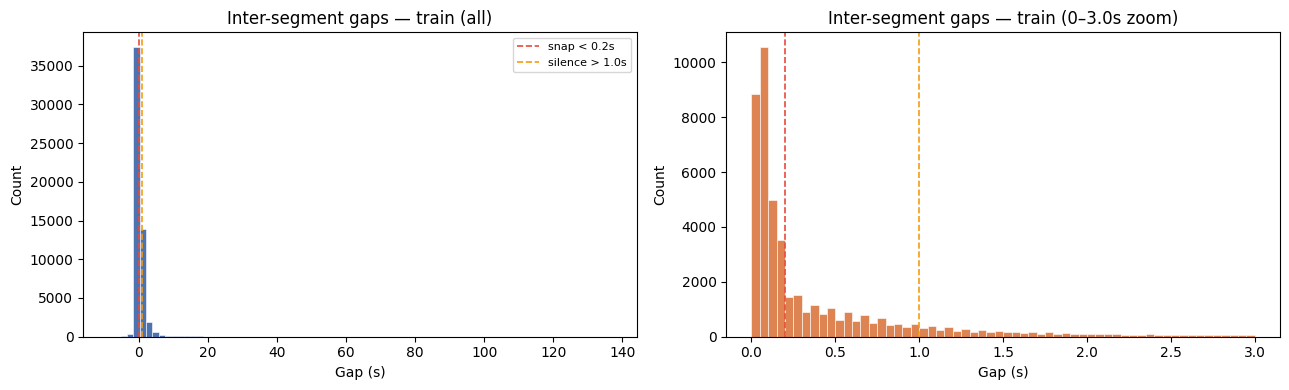

  Gaps < 0.2s (snap)    : 34,989
  Gaps > 1.0s (silence)  : 7,548


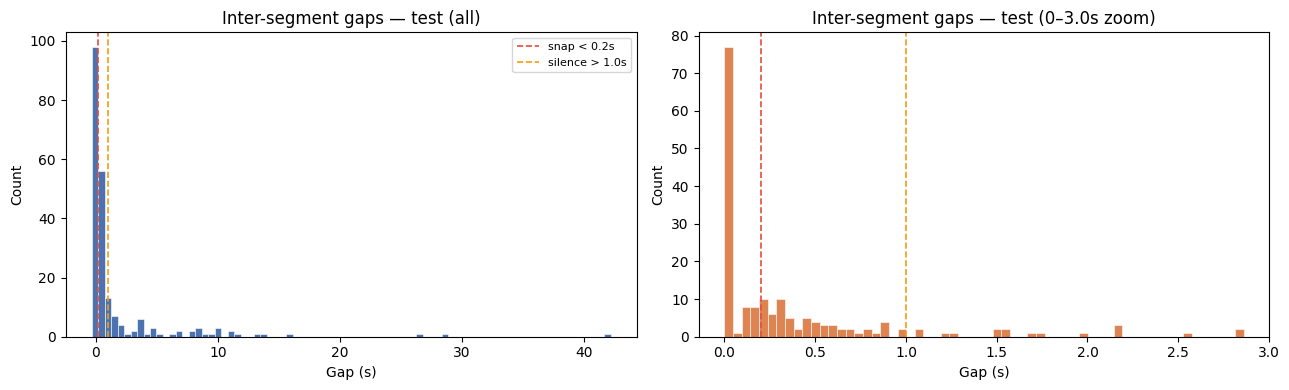

  Gaps < 0.2s (snap)    : 106
  Gaps > 1.0s (silence)  : 50


In [11]:
# ── Gap distribution plots (full + zoomed) ───────────────────
plot_gap_distribution(df_train, SMOOTH_CFG, DISP_CFG, "train", save_path=f"{FIGURES_PATH}/audio_gap_distribution_train.png")
plot_gap_distribution(df_test, SMOOTH_CFG, DISP_CFG, "test", save_path=f"{FIGURES_PATH}/audio_gap_distribution_test.png")

In [12]:
# ── Segment duration distributions (before smoothing) ────────────────────
stats_train = segment_duration_stats(df_train)
stats_test  = segment_duration_stats(df_test)

comp = pd.DataFrame({
    "metric": list(stats_train.keys()),
    "train":  list(stats_train.values()),
    "test":   list(stats_test.values()),
})
print(comp.to_string(index=False))
print()
print(f"Quality gate will flag:")
print(f"  < {GATE_CFG['min_duration_s']}s  (too short) : "
      f"train {(df_train['seg_duration'] < GATE_CFG['min_duration_s']).sum():,}  "
      f"test {(df_test['seg_duration'] < GATE_CFG['min_duration_s']).sum():,}")
print(f"  > {GATE_CFG['max_duration_s']}s  (too long)  : "
      f"train {(df_train['seg_duration'] > GATE_CFG['max_duration_s']).sum():,}  "
      f"test {(df_test['seg_duration'] > GATE_CFG['max_duration_s']).sum():,}")

     metric      train     test
 n_segments 76080.0000 1013.000
total_hours    81.9442    1.239
     mean_s     3.8770    4.403
   median_s     3.5250    3.660
      std_s     2.6530    2.909
      min_s     0.0400    0.518
      max_s    41.4400   15.000
      pct_5     0.5610    1.254
     pct_95     8.5550   11.042

Quality gate will flag:
  < 0.5s  (too short) : train 2,935  test 0
  > 20.0s  (too long)  : train 19  test 0


## 4 · Optional Gap Smoothing

Controlled by `smoothing.enabled` in `configs/audio_config.yaml`.
When enabled, `seg_end` values are adjusted in-place on the DataFrames and the
updated versions are saved back to `data/interim/text_clean/` so the audio
extraction step uses the smoothed boundaries.

A `smoothing_applied` boolean column is added to mark every row that changed.

In [14]:
if SMOOTHING_ENABLED:
    print("Applying gap smoothing …")
    df_train_pre = df_train.copy()   # keep originals for comparison
    df_test_pre  = df_test.copy()

    df_train = apply_smoothing_to_df(
        df_train,
        small_gap=SMOOTH_CFG["small_gap"],
        large_gap=SMOOTH_CFG["large_gap"],
        max_extension=SMOOTH_CFG["max_extension"],
        fill_ratio=SMOOTH_CFG["fill_ratio"],
    )
    df_test = apply_smoothing_to_df(
        df_test,
        small_gap=SMOOTH_CFG["small_gap"],
        large_gap=SMOOTH_CFG["large_gap"],
        max_extension=SMOOTH_CFG["max_extension"],
        fill_ratio=SMOOTH_CFG["fill_ratio"],
    )

    s_train = smoothing_summary(df_train_pre, df_train)
    s_test  = smoothing_summary(df_test_pre,  df_test)
    print_dict(s_train, "Smoothing summary — train")
    print_dict(s_test,  "Smoothing summary — test")
else:
    # Ensure the smoothing_applied column exists even when skipped
    df_train["smoothing_applied"] = False
    df_test["smoothing_applied"]  = False
    print("Smoothing DISABLED — seg_start/seg_end unchanged.")

Smoothing DISABLED — seg_start/seg_end unchanged.


In [15]:
if SMOOTHING_ENABLED:
    # ── Visual before/after comparison ────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    clip = DISP_CFG["duration_clip_s"]

    for ax, df_before, df_after, label, c1, c2 in [
        (axes[0], df_train_pre, df_train, "train", "#4C72B0", "#55A868"),
        (axes[1], df_test_pre,  df_test,  "test",  "#DD8452", "#9C27B0"),
    ]:
        dur_before = (df_before["seg_end"] - df_before["seg_start"]).clip(upper=clip)
        dur_after  = (df_after["seg_end"]  - df_after["seg_start"]).clip(upper=clip)
        ax.hist(dur_before, bins=60, color=c1, alpha=0.6, edgecolor="white",
                linewidth=0.3, label="before")
        ax.hist(dur_after,  bins=60, color=c2, alpha=0.6, edgecolor="white",
                linewidth=0.3, label="after")
        ax.set_title(f"Duration distribution — {label}")
        ax.set_xlabel("Duration (s)")
        ax.set_ylabel("Segments")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"{FIGURES_PATH}/audio_smoothing_before_after.png", bbox_inches="tight")
    plt.show()
    print("✓ Saved audio_smoothing_before_after.png")

In [16]:
# ── Persist updated DataFrames if smoothing was applied ───────────────────
# We overwrite the Phase 3 output files so that the audio extraction step
# uses the smoothed boundaries.  The `smoothing_applied` column records
# exactly which rows changed.
if SMOOTHING_ENABLED:
    df_train.to_parquet(f"{TEXT_CLEAN_DIR}/df_train_clean.parquet", index=False)
    df_test.to_parquet(f"{TEXT_CLEAN_DIR}/df_test_clean.parquet",  index=False)
    print(f"✓ Updated parquets saved to {TEXT_CLEAN_DIR}")
    print(f"  Smoothed: train={df_train['smoothing_applied'].sum():,}  "
          f"test={df_test['smoothing_applied'].sum():,}")

## 5 · Preprocessing Spot-Check

Decode, slice, and preprocess a small number of segments to visually confirm
the transform chain (mono, resample, trim, normalise, pre-emphasis) before
launching the full extraction loop.

In [18]:
from IPython.display import Audio as IPAudio, display

N_CHECK = DISP_CFG["n_spot_check"]
# Pick N_CHECK random segments from different recordings
sample_rows = df_train.sample(N_CHECK, random_state=42)

# Build recording→HF index
rec_to_idx = {train_dataset[i]["audio_id"]: i for i in range(len(train_dataset))}

for _, row in sample_rows.iterrows():
    rec_id  = "_".join(row["audio_id"].split("_")[:-1])
    hf_idx  = rec_to_idx.get(rec_id)
    if hf_idx is None:
        print(f"  ⚠ Recording {rec_id} not found — skipping"); continue

    audio_bytes = train_dataset[hf_idx]["audio"]["bytes"]
    raw_wave, orig_sr = decode_audio_bytes(audio_bytes)
    seg_wave = slice_segment(raw_wave, orig_sr, float(row["seg_start"]), float(row["seg_end"]))
    proc_wave, out_sr = full_preprocess(
        seg_wave, orig_sr,
        target_sr=PP_CFG["target_sr"],
        do_mono=PP_CFG["do_mono"],
        do_resample=PP_CFG["do_resample"],
        do_trim=PP_CFG["do_trim"],
        do_normalize=PP_CFG["do_normalize"],
        do_pre_emphasis=PP_CFG["do_pre_emphasis"],
        normalize_level=PP_CFG["normalize_level"],
        pre_emphasis_coef=PP_CFG["pre_emphasis_coef"],
        trim_top_db=PP_CFG["trim_top_db"],
    )
    metrics = compute_segment_quality(proc_wave, out_sr)
    passed, reason = passes_quality_gate(metrics, **GATE_CFG)

    print(f"  audio_id    : {row['audio_id']}")
    print(f"  seg         : {row['seg_start']:.2f}s – {row['seg_end']:.2f}s")
    print(f"  raw shape   : {seg_wave.shape}  sr={orig_sr}")
    print(f"  proc shape  : {proc_wave.shape}  sr={out_sr}")
    print(f"  RMS={metrics['rms']:.4f}  silence={metrics['silence_ratio']:.2%}  dur={metrics['duration_s']:.2f}s")
    print(f"  gate        : {'✓ kept' if passed else f'✗ dropped ({reason})'}")
    if "transcript_nota" in row:
        print(f"  transcript  : {str(row['transcript_nota'])[:80]}")
    print()
    display(IPAudio(proc_wave, rate=out_sr))

  audio_id    : youtube_tO5sk5Xk0-Y_26
  seg         : 149.04s – 153.67s
  raw shape   : (74000,)  sr=16000
  proc shape  : (74000,)  sr=16000
  RMS=0.0736  silence=31.65%  dur=4.62s
  gate        : ✓ kept
  transcript  : فاطمه بنت خالته فاطمه عرس بها الساعه بعد



  audio_id    : amenyKH_MIC0000001_mod_0000043_chunk_0000001_MIC00001_mod_43_chunk_1_0
  seg         : 0.00s – 2.62s
  raw shape   : (41970,)  sr=16000
  proc shape  : (26368,)  sr=16000
  RMS=0.0565  silence=31.56%  dur=1.65s
  gate        : ✓ kept
  transcript  : مرحبا



  audio_id    : youtube_QDVsnUGhvoY_139
  seg         : 571.42s – 575.49s
  raw shape   : (65056,)  sr=16000
  proc shape  : (63872,)  sr=16000
  RMS=0.0203  silence=68.86%  dur=3.99s
  gate        : ✓ kept
  transcript  : العامله ولا وين يحل الباب يلقاها واقفت



  audio_id    : youtube_oGQPyCGoWbs_811
  seg         : 3300.72s – 3305.25s
  raw shape   : (72416,)  sr=16000
  proc shape  : (72416,)  sr=16000
  RMS=0.0297  silence=65.36%  dur=4.53s
  gate        : ✓ kept
  transcript  : محمد يا على ق شنوا رسول محمد عل تطلق ك



  audio_id    : youtube_ey0_hdCWF7s_407
  seg         : 1683.69s – 1685.59s
  raw shape   : (30448,)  sr=16000
  proc shape  : (30448,)  sr=16000
  RMS=0.0393  silence=56.21%  dur=1.90s
  gate        : ✓ kept
  transcript  : خرج من البلاد برا تبع اذا كان



## 6 · Full Extraction Loop

**This is the computationally expensive step.**  Each recording is loaded once
and all its segments are sliced, preprocessed, and quality-checked in a single
pass.  Outputs:

- `data/interim/audio_clean/{train,test}/segments.arrow` — preprocessed
  float32 waveforms for every *kept* segment (Arrow IPC, memory-mappable)
- `data/interim/audio_clean/{train,test}/manifest.parquet` — full
  metadata for *all* segments including dropped ones

> ⏱ Expected time: ~15–30 min for the full 76 k-segment train split on CPU,
> depending on disk speed.  Use `--dry-run` in `run_audio_pipeline.py` for
> quick smoke tests.

In [20]:
# ── Build preprocessing kwargs from config ───────────────────────────────
preprocess_kwargs = {
    "target_sr":          PP_CFG["target_sr"],
    "do_mono":            PP_CFG["do_mono"],
    "do_resample":        PP_CFG["do_resample"],
    "do_trim":            PP_CFG["do_trim"],
    "do_normalize":       PP_CFG["do_normalize"],
    "do_pre_emphasis":    PP_CFG["do_pre_emphasis"],
    "normalize_level":    PP_CFG["normalize_level"],
    "pre_emphasis_coef":  PP_CFG["pre_emphasis_coef"],
    "trim_top_db":        PP_CFG["trim_top_db"],
}

gate_kwargs = {
    "min_duration_s":    GATE_CFG["min_duration_s"],
    "max_duration_s":    GATE_CFG["max_duration_s"],
    "min_rms":           GATE_CFG["min_rms"],
    "max_silence_ratio": GATE_CFG["max_silence_ratio"],
}

print("Preprocessing chain:")
for k, v in preprocess_kwargs.items():
    print(f"  {k:<22} {v}")
print()
print("Quality gate:")
for k, v in gate_kwargs.items():
    print(f"  {k:<22} {v}")

Preprocessing chain:
  target_sr              16000
  do_mono                False
  do_resample            True
  do_trim                True
  do_normalize           True
  do_pre_emphasis        True
  normalize_level        0.95
  pre_emphasis_coef      0.97
  trim_top_db            30.0

Quality gate:
  min_duration_s         0.5
  max_duration_s         20.0
  min_rms                0.001
  max_silence_ratio      0.9


In [21]:
import time

# ── TRAIN split ───────────────────────────────────────────────────────────
print("Processing TRAIN split …")

#  check first
exists, arrow_train, manifest_train = outputs_exist(AUDIO_OUT_DIR, "train")

if exists:
    print("✓ Train already processed — skipping")
    print(f"  Arrow    → {arrow_train}")
    print(f"  Manifest → {manifest_train}")
else:
    t0 = time.perf_counter()
    train_segments = list(iter_segments(
        train_dataset, df_train,
        preprocess_kwargs=preprocess_kwargs,
        gate_kwargs=gate_kwargs,
        split_name="train",
    ))
    arrow_train, manifest_train = save_segments_arrow(
        train_segments, AUDIO_OUT_DIR, "train",
        kept_only=STORE_CFG["kept_only"],
    )
    elapsed = time.perf_counter() - t0
    print(f"✓ Train done in {elapsed/60:.1f} min")
    print(f"  Arrow    → {arrow_train}")
    print(f"  Manifest → {manifest_train}")

Processing TRAIN split …


Extracting [train]:   0%|          | 0/20883 [00:00<?, ?it/s]

✓ Train done in 11.8 min
  Arrow    → C:\Users\MSI\Desktop\ASR\asr_tn_pielines\data\interim\audio_clean\train\segments.arrow
  Manifest → C:\Users\MSI\Desktop\ASR\asr_tn_pielines\data\interim\audio_clean\train\manifest.parquet


In [23]:
# ── TEST split ────────────────────────────────────────────────────────────
print("Processing TEST split …")

exists, arrow_test, manifest_test = outputs_exist(AUDIO_OUT_DIR, "test")

if exists:
    print("✓ Test already processed — skipping")
    print(f"  Arrow    → {arrow_test}")
    print(f"  Manifest → {manifest_test}")
else:
    t0 = time.perf_counter()
    
    test_segments = list(iter_segments(
        test_dataset, df_test,
        preprocess_kwargs=preprocess_kwargs,
        gate_kwargs=gate_kwargs,
        split_name="test",
    ))
    
    arrow_test, manifest_test = save_segments_arrow(
        test_segments, AUDIO_OUT_DIR, "test",
        kept_only=STORE_CFG["kept_only"],
    )
    
    elapsed = time.perf_counter() - t0
    print(f"✓ Test done in {elapsed/60:.1f} min")
    print(f"  Arrow    → {arrow_test}")
    print(f"  Manifest → {manifest_test}")

Processing TEST split …


Extracting [test]:   0%|          | 0/799 [00:00<?, ?it/s]

✓ Test done in 0.5 min
  Arrow    → C:\Users\MSI\Desktop\ASR\asr_tn_pielines\data\interim\audio_clean\test\segments.arrow
  Manifest → C:\Users\MSI\Desktop\ASR\asr_tn_pielines\data\interim\audio_clean\test\manifest.parquet


## 7 · Post-Processing Statistics

In [25]:
# ── Reload manifests ─────────────────────────────────────────────────────
from pathlib import Path as _P
mdf_train = load_manifest(_P(AUDIO_OUT_DIR) / "train" / "manifest.parquet")
mdf_test  = load_manifest(_P(AUDIO_OUT_DIR) / "test"  / "manifest.parquet")

stats_tr = compute_corpus_stats(mdf_train)
stats_te = compute_corpus_stats(mdf_test)

print_dict(stats_tr, "Corpus stats — train")
print_dict(stats_te, "Corpus stats — test")


──────────────────────────────────────────────────
  Corpus stats — train
──────────────────────────────────────────────────
  n_total                             76080
  n_kept                              72314
  n_dropped                           3766
  pct_kept                            95.05
  total_hours_kept                    76.242
  mean_duration_s                     3.796
  median_duration_s                   3.466
  std_duration_s                      2.429
  min_duration_s                      0.5
  max_duration_s                      19.984
  mean_rms                            0.044124
  drop_reasons                        {'too_short': 3588, 'mostly_silent': 161, 'too_long': 14, 'too_silent': 3}

──────────────────────────────────────────────────
  Corpus stats — test
──────────────────────────────────────────────────
  n_total                             1013
  n_kept                              1005
  n_dropped                           8
  pct_kept              

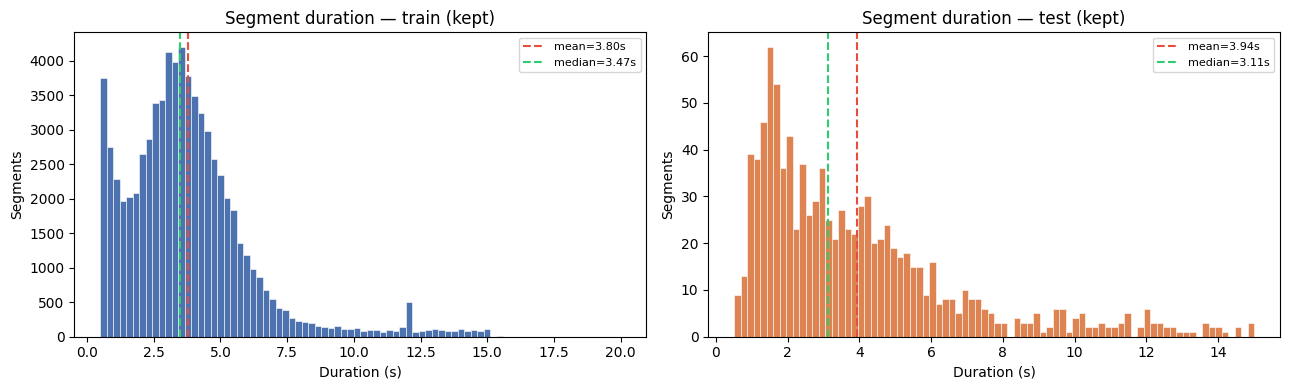

✓ Saved audio_duration_distribution.png


In [26]:
# ── Duration distribution (kept segments) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
clip = DISP_CFG["duration_clip_s"]

for ax, mdf, label, color in [
    (axes[0], mdf_train[mdf_train["kept"]], "train", "#4C72B0"),
    (axes[1], mdf_test[mdf_test["kept"]],   "test",  "#DD8452"),
]:
    dur = mdf["duration_s"].clip(upper=clip)
    ax.hist(dur, bins=80, color=color, edgecolor="white", linewidth=0.4)
    ax.axvline(dur.mean(),   color="#E74C3C", lw=1.5, ls="--",
               label=f"mean={dur.mean():.2f}s")
    ax.axvline(dur.median(), color="#2ECC71", lw=1.5, ls="--",
               label=f"median={dur.median():.2f}s")
    ax.set_title(f"Segment duration — {label} (kept)")
    ax.set_xlabel("Duration (s)"); ax.set_ylabel("Segments")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/audio_duration_distribution.png", bbox_inches="tight")
plt.show()
print("✓ Saved audio_duration_distribution.png")

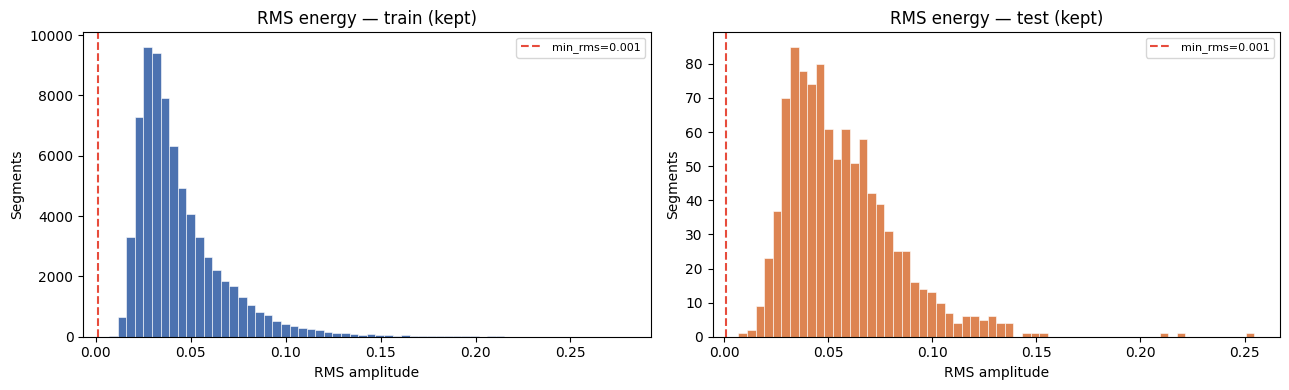

✓ Saved audio_rms_distribution.png


In [27]:
# ── RMS energy distribution ───────────────────────────────────────────────
if "rms" in mdf_train.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    bins = DISP_CFG["rms_hist_bins"]
    for ax, mdf, label, color in [
        (axes[0], mdf_train[mdf_train["kept"]], "train", "#4C72B0"),
        (axes[1], mdf_test[mdf_test["kept"]],   "test",  "#DD8452"),
    ]:
        ax.hist(mdf["rms"].clip(upper=0.5), bins=bins, color=color,
                edgecolor="white", linewidth=0.4)
        ax.axvline(GATE_CFG["min_rms"], color="#E74C3C", lw=1.5, ls="--",
                   label=f"min_rms={GATE_CFG['min_rms']}")
        ax.set_title(f"RMS energy — {label} (kept)")
        ax.set_xlabel("RMS amplitude"); ax.set_ylabel("Segments")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_PATH}/audio_rms_distribution.png", bbox_inches="tight")
    plt.show()
    print("✓ Saved audio_rms_distribution.png")

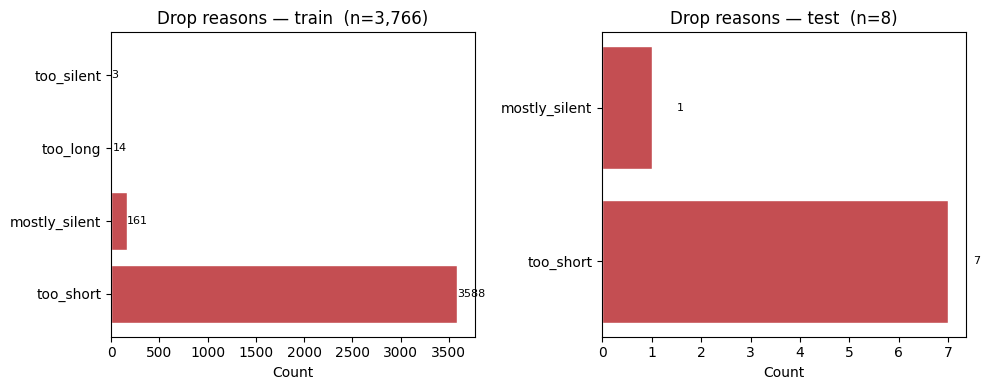

✓ Saved audio_drop_reasons.png


In [28]:
# ── Drop-reason breakdown ─────────────────────────────────────────────────
dropped_tr = mdf_train[mdf_train["kept"] == False]
dropped_te = mdf_test[mdf_test["kept"]  == False]

if len(dropped_tr) + len(dropped_te) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, dropped, label in [
        (axes[0], dropped_tr, "train"),
        (axes[1], dropped_te, "test"),
    ]:
        if len(dropped) == 0:
            ax.text(0.5, 0.5, "No dropped segments", ha="center", va="center")
            ax.set_title(f"Drop reasons — {label}")
            continue
        counts = dropped["drop_reason"].value_counts()
        ax.barh(counts.index, counts.values, color="#C44E52", edgecolor="white")
        ax.set_title(f"Drop reasons — {label}  (n={len(dropped):,})")
        ax.set_xlabel("Count")
        for i, v in enumerate(counts.values):
            ax.text(v + 0.5, i, str(v), va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_PATH}/audio_drop_reasons.png", bbox_inches="tight")
    plt.show()
    print("✓ Saved audio_drop_reasons.png")
else:
    print("No dropped segments — quality gate accepted all.")

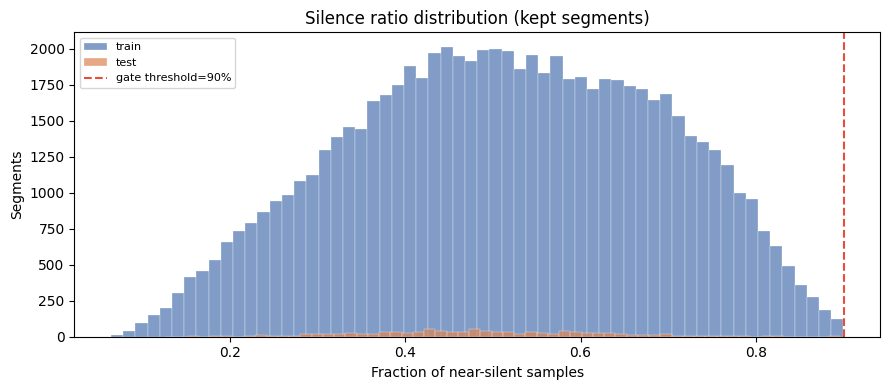

✓ Saved audio_silence_ratio.png


In [29]:
# ── Silence ratio distribution ────────────────────────────────────────────
if "silence_ratio" in mdf_train.columns:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(mdf_train[mdf_train["kept"]]["silence_ratio"], bins=60,
            color="#4C72B0", alpha=0.7, edgecolor="white", linewidth=0.3, label="train")
    ax.hist(mdf_test[mdf_test["kept"]]["silence_ratio"],   bins=60,
            color="#DD8452", alpha=0.7, edgecolor="white", linewidth=0.3, label="test")
    ax.axvline(GATE_CFG["max_silence_ratio"], color="#E74C3C", lw=1.5, ls="--",
               label=f"gate threshold={GATE_CFG['max_silence_ratio']:.0%}")
    ax.set_title("Silence ratio distribution (kept segments)")
    ax.set_xlabel("Fraction of near-silent samples"); ax.set_ylabel("Segments")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_PATH}/audio_silence_ratio.png", bbox_inches="tight")
    plt.show()
    print("✓ Saved audio_silence_ratio.png")

## 8 · Summary Report

In [31]:
print_section("AUDIO PREPROCESSING — SUMMARY")

for label, stats, mdf in [
    ("Train", stats_tr, mdf_train),
    ("Test",  stats_te, mdf_test),
]:
    print_dict({
        "Split                   ": label,
        "Input segments          ": f"{stats['n_total']:,}",
        "Kept segments           ": f"{stats['n_kept']:,}  ({stats['pct_kept']:.1f}%)",
        "Dropped segments        ": f"{stats['n_dropped']:,}",
        "Total audio (kept)      ": f"{stats['total_hours_kept']:.3f} hours",
        "Mean duration (kept)    ": f"{stats['mean_duration_s']:.3f} s",
        "Median duration (kept)  ": f"{stats['median_duration_s']:.3f} s",
        "Mean RMS (kept)         ": f"{stats['mean_rms']:.5f}",
        "Drop reasons            ": str(stats['drop_reasons']),
        "Smoothing applied       ": str(SMOOTHING_ENABLED),
        "Target sample rate      ": f"{PP_CFG['target_sr']} Hz",
    }, title=f"{label} split")
    print()

print(f"Outputs:")
print(f"  Arrow (train) : {arrow_train}")
print(f"  Arrow (test)  : {arrow_test}")
print(f"  Manifests in  : {AUDIO_OUT_DIR}/{{train,test}}/manifest.parquet")


════════════════════════════════════════════════════════════
  AUDIO PREPROCESSING — SUMMARY
════════════════════════════════════════════════════════════

──────────────────────────────────────────────────
  Train split
──────────────────────────────────────────────────
  Split                               Train
  Input segments                      76,080
  Kept segments                       72,314  (95.0%)
  Dropped segments                    3,766
  Total audio (kept)                  76.242 hours
  Mean duration (kept)                3.796 s
  Median duration (kept)              3.466 s
  Mean RMS (kept)                     0.04412
  Drop reasons                        {'too_short': 3588, 'mostly_silent': 161, 'too_long': 14, 'too_silent': 3}
  Smoothing applied                   False
  Target sample rate                  16000 Hz


──────────────────────────────────────────────────
  Test split
──────────────────────────────────────────────────
  Split                        